# FreshVision CNN 

This version fixes the runtime problems in the original notebook:
- defines the missing `load_image()` function correctly
- calculates **precision** before using it in the final results
- uses safer dataset splitting
- avoids the very large `Flatten()` layer to reduce memory usage
- handles image decoding/resizing consistently
- saves the model and class names


TensorFlow: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Using dataset root: /kaggle/input/datasets/siavash93/freshness44/Freshness44
Total labeled images found: 53,616
Food type categories found: 22
Number of food type classes: 22
['apple', 'banana', 'bellpepper', 'bitter gourd', 'carrot', 'cucumber', 'grape', 'grapes', 'guava', 'jujube', 'kaki', 'lime', 'mango', 'orange', 'papaya', 'peach', 'pear', 'pomegranate', 'potato', 'strawberry', 'tomato', 'watermelon']


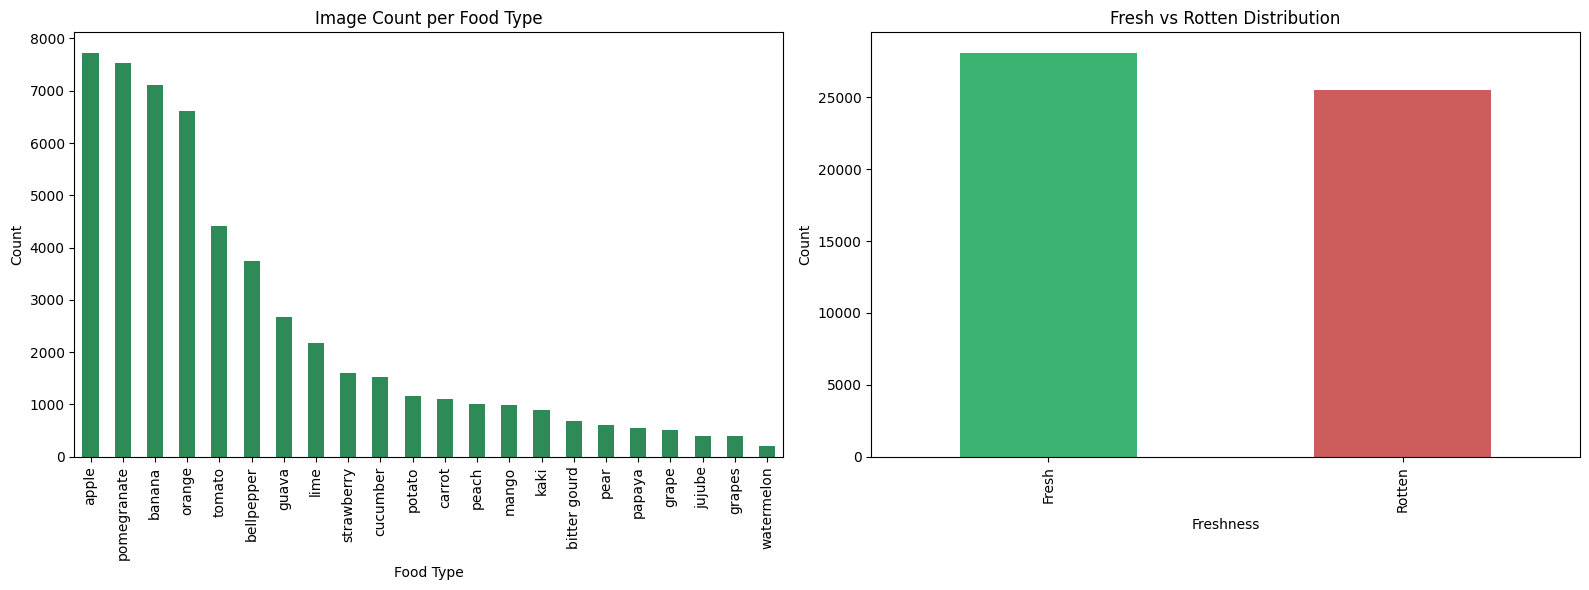

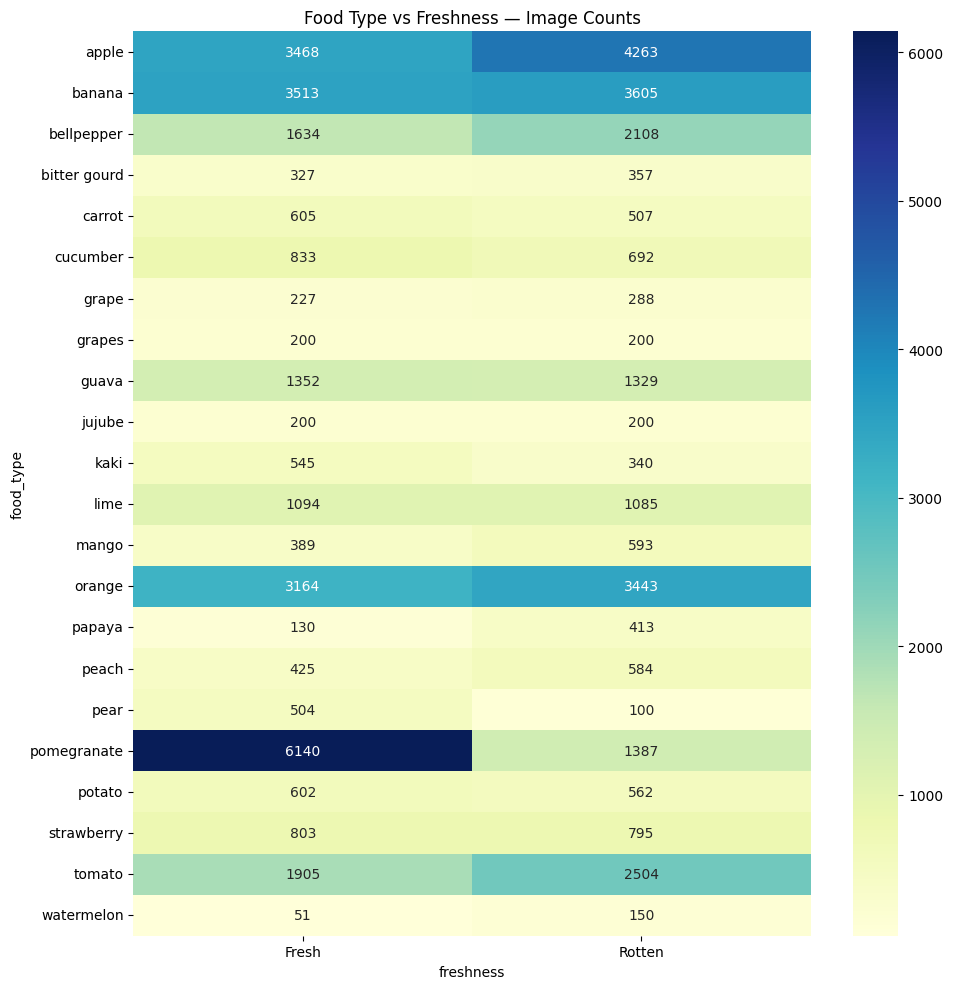

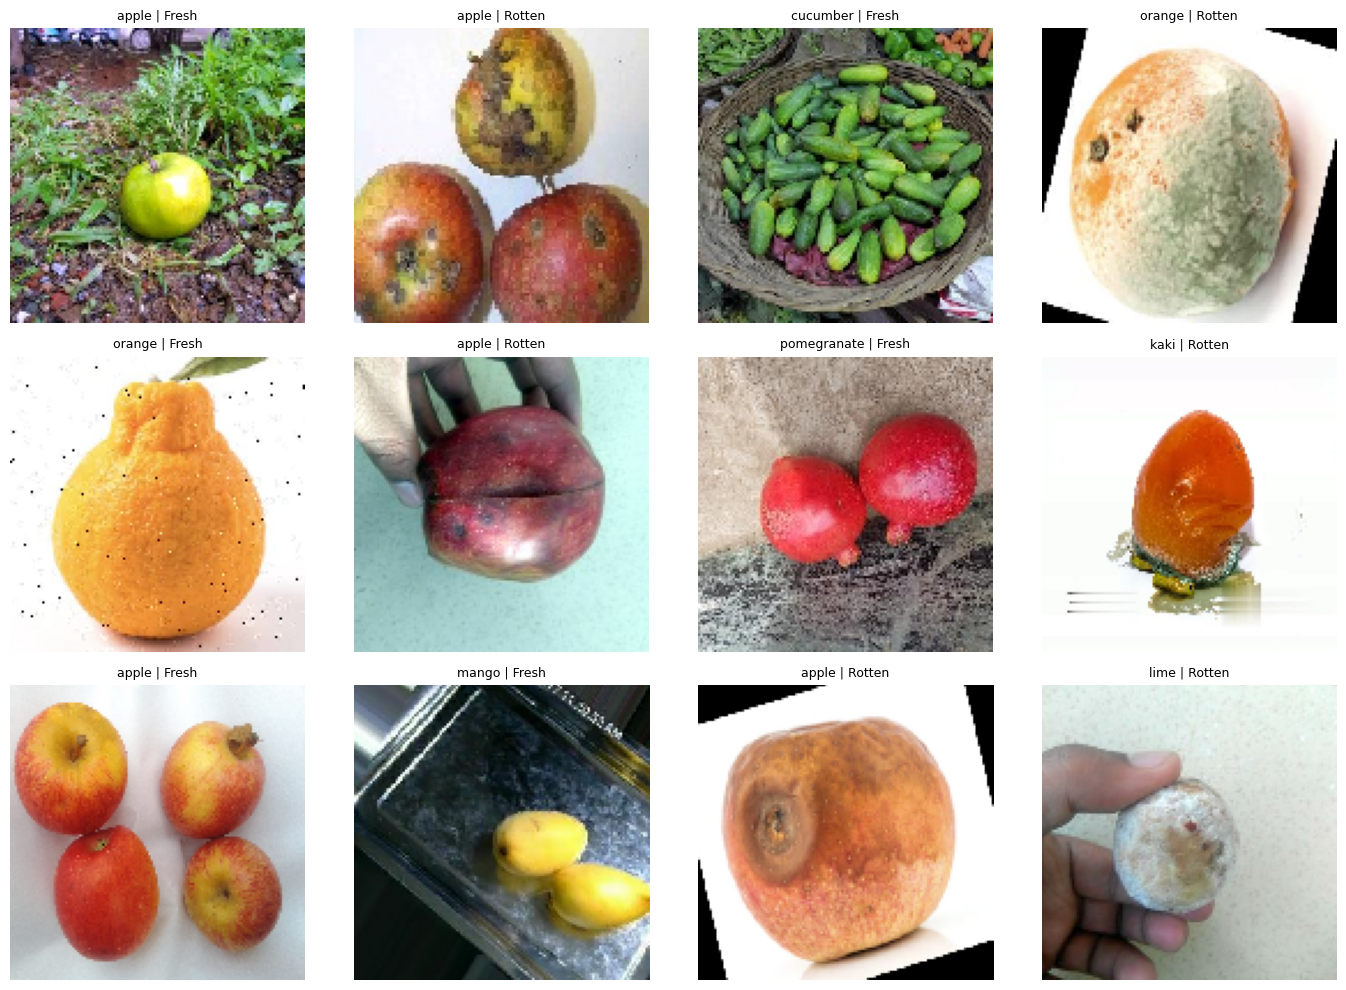

Train: 37,531  Val: 8,042  Test: 8,043
Food type class weights (sample): {0: np.float64(0.31521702613720354), 1: np.float64(0.34242363417393523), 2: np.float64(0.6511276891047884), 3: np.float64(3.561491744163978), 4: np.float64(2.18992881316373)} ...
Freshness class weights: {0: np.float64(1.0511707371723056), 1: np.float64(0.953579958331216)}


Model: "FreshVision_CNN_MultiTask"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │        896 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_6[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_features     │ (None, 256)       │          0 │ max_pooling2d_7[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     65,792 │ shared_features[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     32,896 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │     16,448 │ dropout_3[0][0] 

 Total params: 508,375 (1.94 MB)

 Trainable params: 507,415 (1.94 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/30
1173/1173 ━━━━━━━━━━━━━━━━━━━━ 189s 148ms/step - food_type_output_accuracy: 0.5948 - food_type_output_loss: 1.2939 - freshness_output_accuracy: 0.7874 - freshness_output_loss: 0.4519 - loss: 1.7460 - val_food_type_output_accuracy: 0.7232 - val_food_type_output_loss: 0.9035 - val_freshness_output_accuracy: 0.8476 - val_freshness_output_loss: 0.3610 - val_loss: 1.2645 - learning_rate: 0.0010
Epoch 2/30
1173/1173 ━━━━━━━━━━━━━━━━━━━━ 183s 151ms/step - food_type_output_accuracy: 0.7677 - food_type_output_loss: 0.7406 - freshness_output_accuracy: 0.8712 - freshness_output_loss: 0.3088 - loss: 1.0495 - val_food_type_output_accuracy: 0.7438 - val_food_type_output_loss: 0.7791 - val_freshness_output_accuracy: 0.8396 - val_freshness_output_loss: 0.3633 - val_loss: 1.1429 - learning_rate: 0.0010
Epoch 3/30
1173/1173 ━━━━━━━━━━━━━━━━━━━━ 176s 144ms/step - food_type_output_accuracy: 0.8269 - food_type_output_loss: 0.5587 - freshness_output_accuracy: 0.8993 - freshness_output_loss: 0.248

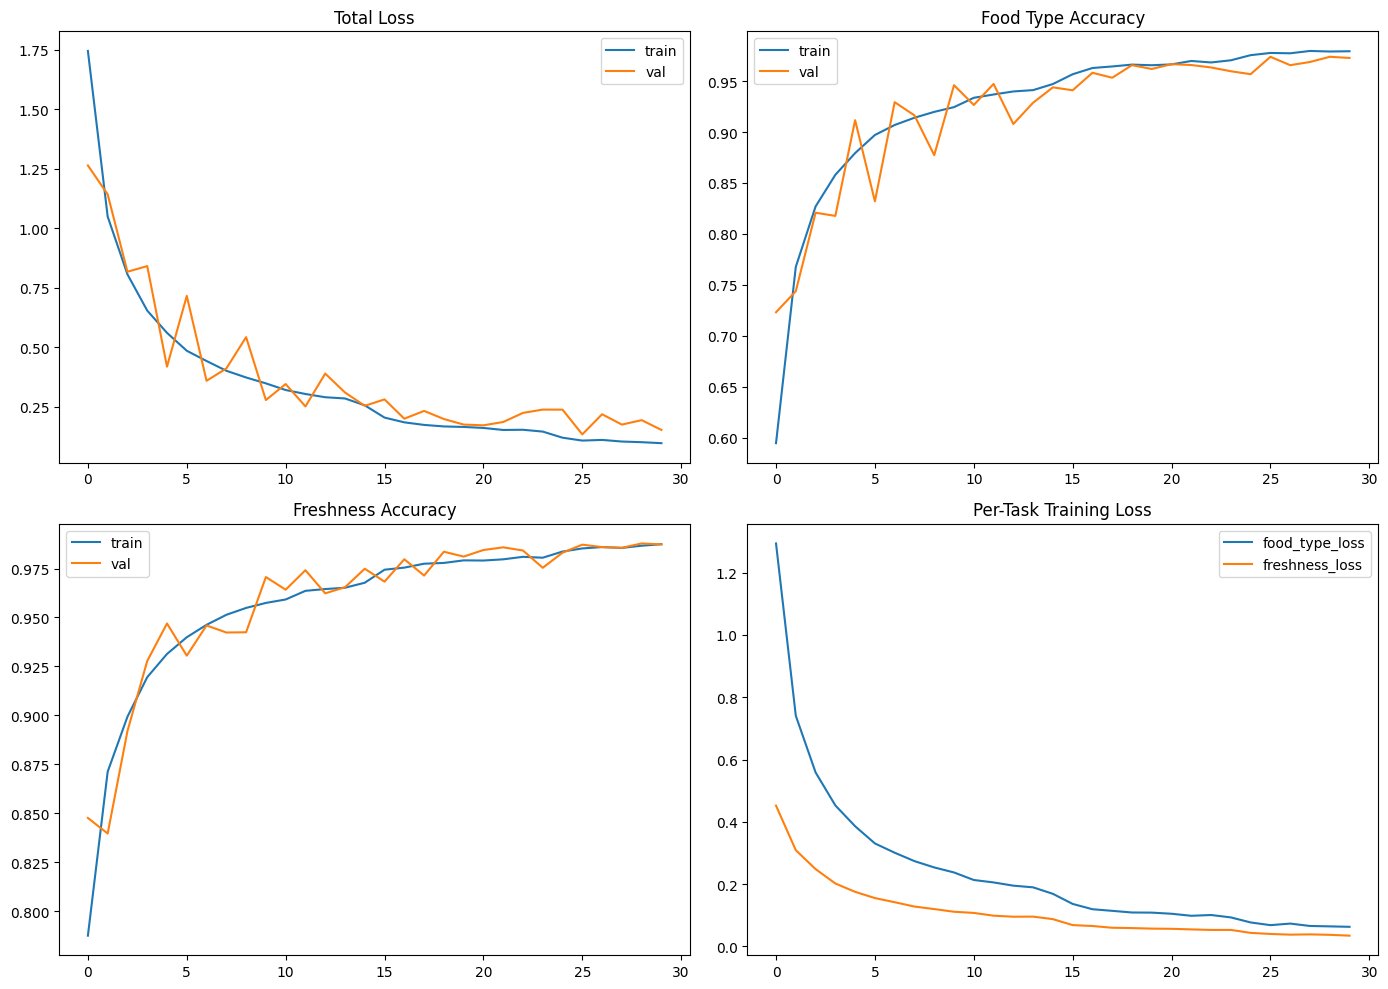

252/252 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - food_type_output_accuracy: 0.9750 - food_type_output_loss: 0.0940 - freshness_output_accuracy: 0.9833 - freshness_output_loss: 0.0399 - loss: 0.1335
Test results:
  food_type_output_accuracy: 0.9750
  food_type_output_loss: 0.0940
  freshness_output_accuracy: 0.9833
  freshness_output_loss: 0.0399
  loss: 0.1335
=== Food Type Classification Report ===
              precision    recall  f1-score   support

       apple     0.9885    0.9672    0.9778      1160
      banana     0.9887    0.9869    0.9878      1068
  bellpepper     0.9922    0.9109    0.9498       561
bitter gourd     0.9903    1.0000    0.9951       102
      carrot     0.8671    0.8982    0.8824       167
    cucumber     0.8725    0.9563    0.9125       229
       grape     1.0000    1.0000    1.0000        77
      grapes     1.0000    1.0000    1.0000        60
       guava     0.9557    0.9628    0.9592       403
      jujube     0.9516    0.9833    0.9672        60
      

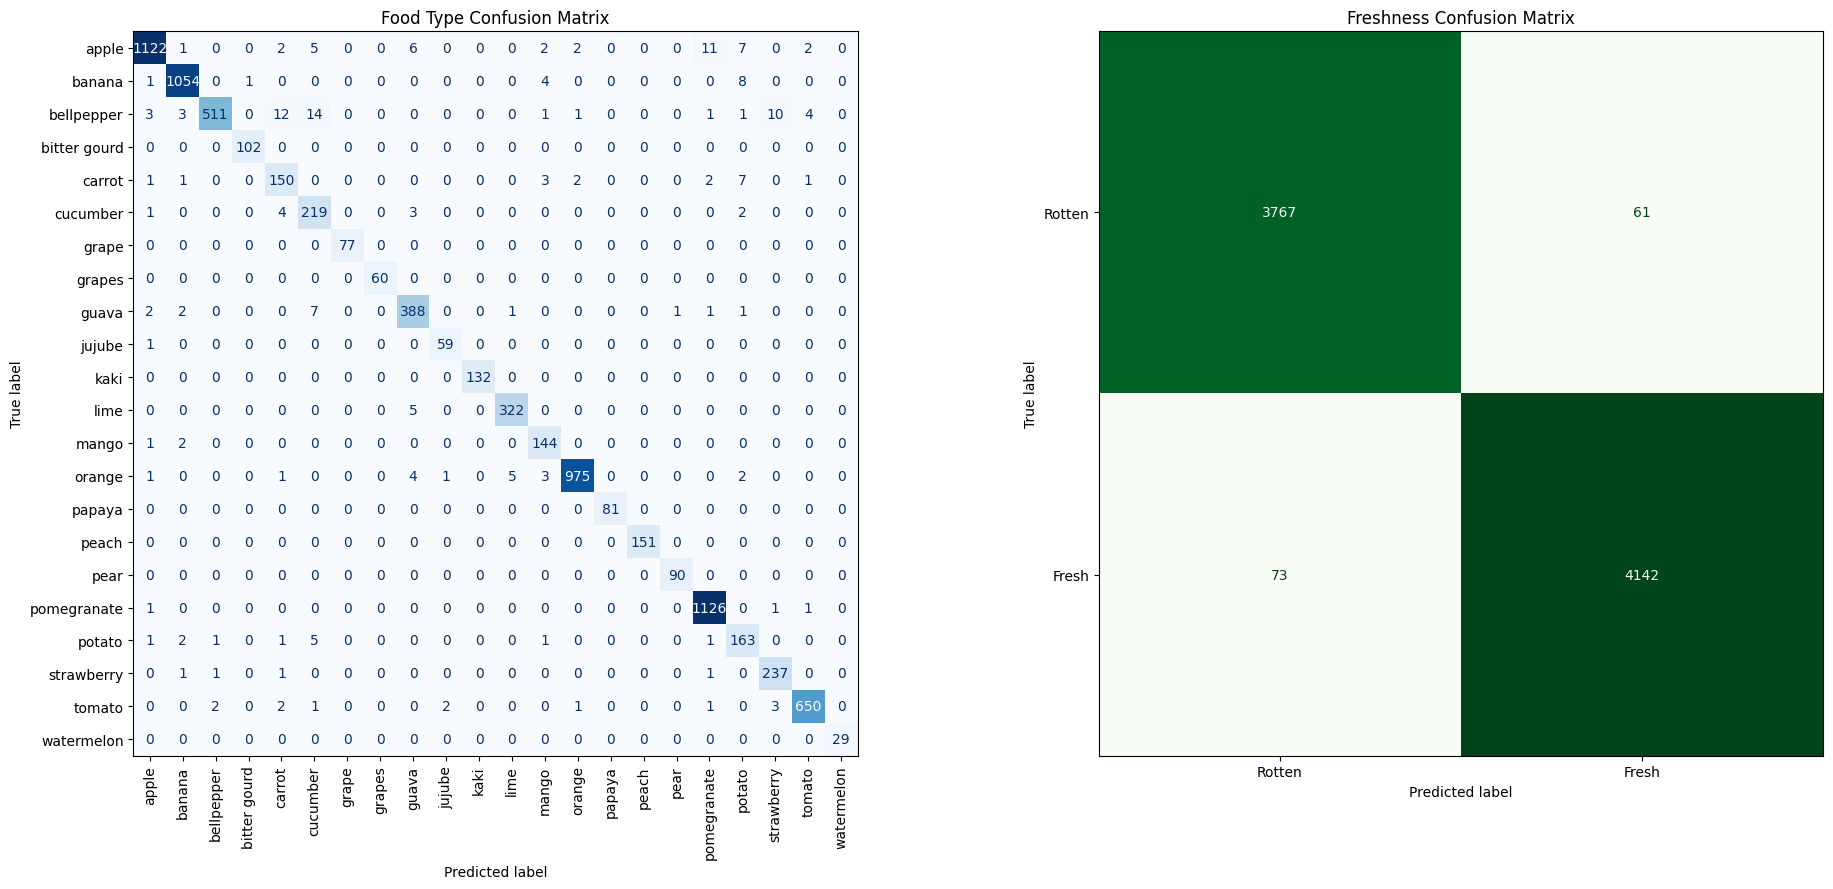

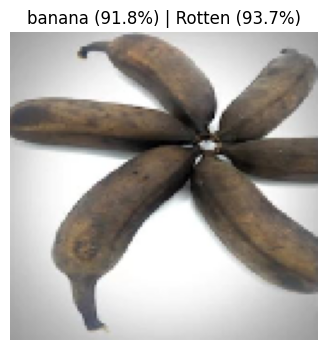

Model saved to freshvision_cnn_final.keras
Artifacts (labels, weights, history, metrics) saved to freshvision_artifacts.pkl


In [5]:
import os
import re
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_recall_fscore_support,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 30
AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))


# ---------------------------------------------------------------------------
# 1. Locate dataset
# ---------------------------------------------------------------------------
DATASET_ROOT = "/kaggle/input"

def find_dataset_dir(root):
    """Locate the Freshness44 dataset folder inside /kaggle/input."""
    candidates = []
    for dirpath, dirnames, filenames in os.walk(root):
        if any(f.lower().endswith((".jpg", ".jpeg", ".png")) for f in filenames):
            candidates.append(dirpath)
    if not candidates:
        raise FileNotFoundError(
            f"No image files found under {root}. Add the Freshness44 dataset via "
            "'+ Add Data' in the Kaggle notebook sidebar."
        )
    # Use the shallowest common ancestor of folders that actually contain images
    return sorted(candidates, key=lambda p: p.count(os.sep))[0]

# If you know the exact path, set it directly instead, e.g.:
# IMAGE_ROOT = "/kaggle/input/freshness44"
IMAGE_ROOT = os.path.dirname(find_dataset_dir(DATASET_ROOT))
print("Using dataset root:", IMAGE_ROOT)


# ---------------------------------------------------------------------------
# 2. Parse labels from folder structure
# ---------------------------------------------------------------------------
def parse_labels_from_path(path, root):
    """Infer (food_type, freshness) from a file's folder path."""
    rel = os.path.relpath(path, root)
    parts = re.split(r"[\\/]", rel)
    folder_tokens = " ".join(parts[:-1]).lower()

    if "rotten" in folder_tokens or "spoiled" in folder_tokens or "stale" in folder_tokens:
        freshness = "Rotten"
    elif "fresh" in folder_tokens:
        freshness = "Fresh"
    else:
        freshness = "Unknown"

    food_type = re.sub(r"(fresh|rotten|spoiled|stale)", "", folder_tokens, flags=re.IGNORECASE)
    food_type = re.sub(r"[^a-z]+", " ", food_type).strip()
    food_type = food_type if food_type else "unknown"
    return food_type, freshness

records = []
for dirpath, _, filenames in os.walk(IMAGE_ROOT):
    for fname in filenames:
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            fpath = os.path.join(dirpath, fname)
            food_type, freshness = parse_labels_from_path(fpath, IMAGE_ROOT)
            records.append({"filepath": fpath, "food_type": food_type, "freshness": freshness})

df = pd.DataFrame(records)
df = df[df["freshness"] != "Unknown"].reset_index(drop=True)
print(f"Total labeled images found: {len(df):,}")
print(f"Food type categories found: {df['food_type'].nunique()}")
df.head()


food_types = sorted(df["food_type"].unique())
food_type_to_idx = {name: i for i, name in enumerate(food_types)}
idx_to_food_type = {i: name for name, i in food_type_to_idx.items()}
NUM_FOOD_CLASSES = len(food_types)

df["food_type_idx"] = df["food_type"].map(food_type_to_idx)
df["freshness_bin"] = (df["freshness"] == "Fresh").astype(int)

print(f"Number of food type classes: {NUM_FOOD_CLASSES}")
print(food_types)


# ---------------------------------------------------------------------------
# 3. Exploratory plots
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df["food_type"].value_counts().plot(kind="bar", ax=axes[0], color="seagreen")
axes[0].set_title("Image Count per Food Type")
axes[0].set_xlabel("Food Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=90)

df["freshness"].value_counts().plot(kind="bar", ax=axes[1], color=["mediumseagreen", "indianred"])
axes[1].set_title("Fresh vs Rotten Distribution")
axes[1].set_xlabel("Freshness")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("eda_distribution.png", dpi=150)
plt.show()


# Cross-tabulation: food type x freshness (helps reveal class imbalance)
cross_tab = pd.crosstab(df["food_type"], df["freshness"])
plt.figure(figsize=(10, 10))
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Food Type vs Freshness — Image Counts")
plt.tight_layout()
plt.savefig("eda_crosstab_heatmap.png", dpi=150)
plt.show()
cross_tab


# Sample images
sample_df = df.sample(n=min(12, len(df)), random_state=SEED)
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, (_, row) in zip(axes.flatten(), sample_df.iterrows()):
    img = tf.keras.utils.load_img(row["filepath"], target_size=IMG_SIZE)
    ax.imshow(img)
    ax.set_title(f"{row['food_type']} | {row['freshness']}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()


# ---------------------------------------------------------------------------
# 4. Train/val/test split
# ---------------------------------------------------------------------------
df["strata"] = df["food_type"].astype(str) + "_" + df["freshness"].astype(str)

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["strata"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["strata"], random_state=SEED
)

print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")


# ---------------------------------------------------------------------------
# 5. tf.data pipelines
# ---------------------------------------------------------------------------
def make_dataset(dataframe, training=False):
    filepaths = dataframe["filepath"].values
    food_labels = dataframe["food_type_idx"].values.astype(np.int32)
    fresh_labels = dataframe["freshness_bin"].values.astype(np.float32)

    def _load(filepath, food_label, fresh_label):
        img = tf.io.read_file(filepath)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        return img, {"food_type_output": food_label, "freshness_output": fresh_label}

    ds = tf.data.Dataset.from_tensor_slices((filepaths, food_labels, fresh_labels))
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=2048, seed=SEED)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
], name="data_augmentation")

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

# Apply augmentation only to the training pipeline, only to the image tensor
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                         num_parallel_calls=AUTOTUNE)


# ---------------------------------------------------------------------------
# 6. Class weights (imbalance mitigation)
# ---------------------------------------------------------------------------
food_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_FOOD_CLASSES),
    y=train_df["food_type_idx"].values,
)
food_class_weight_dict = {i: w for i, w in enumerate(food_class_weights)}

fresh_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["freshness_bin"].values,
)
fresh_class_weight_dict = {0: fresh_class_weights[0], 1: fresh_class_weights[1]}

print("Food type class weights (sample):", dict(list(food_class_weight_dict.items())[:5]), "...")
print("Freshness class weights:", fresh_class_weight_dict)


# ---------------------------------------------------------------------------
# 7. Model definition
# ---------------------------------------------------------------------------
def build_cnn_multitask(input_shape=(*IMG_SIZE, 3), num_food_classes=NUM_FOOD_CLASSES):
    inputs = layers.Input(shape=input_shape, name="image_input")

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    shared = layers.GlobalAveragePooling2D(name="shared_features")(x)
    shared = layers.Dense(256, activation="relu")(shared)
    shared = layers.Dropout(0.4)(shared)

    # Food type head (softmax)
    food_branch = layers.Dense(128, activation="relu")(shared)
    food_branch = layers.Dropout(0.3)(food_branch)
    food_output = layers.Dense(num_food_classes, activation="softmax",
                                name="food_type_output")(food_branch)

    # Freshness head (binary sigmoid)
    fresh_branch = layers.Dense(64, activation="relu")(shared)
    fresh_branch = layers.Dropout(0.3)(fresh_branch)
    fresh_output = layers.Dense(1, activation="sigmoid",
                                 name="freshness_output")(fresh_branch)

    model = models.Model(inputs=inputs, outputs=[food_output, fresh_output],
                          name="FreshVision_CNN_MultiTask")
    return model

model = build_cnn_multitask()
model.summary()


# ---------------------------------------------------------------------------
# 8. Compile & train
# ---------------------------------------------------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        "food_type_output": "sparse_categorical_crossentropy",
        "freshness_output": "binary_crossentropy",
    },
    loss_weights={"food_type_output": 1.0, "freshness_output": 1.0},
    metrics={
        "food_type_output": ["accuracy"],
        "freshness_output": ["accuracy"],
    },
)

callback_list = [
    callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    callbacks.ModelCheckpoint("freshvision_cnn_best.keras", monitor="val_loss",
                               save_best_only=True),
]

# Note: per-sample class weighting isn't natively supported for multi-output Keras
# models with a single combined weight; food_class_weight_dict / fresh_class_weight_dict
# above document the imbalance mitigation strategy and can be wired in via a
# custom tf.data weighting step if per-sample weights are required experimentally.

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callback_list,
)


# ---------------------------------------------------------------------------
# 9. Training curves
# ---------------------------------------------------------------------------
hist = history.history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(hist["loss"], label="train")
axes[0, 0].plot(hist["val_loss"], label="val")
axes[0, 0].set_title("Total Loss"); axes[0, 0].legend()

axes[0, 1].plot(hist["food_type_output_accuracy"], label="train")
axes[0, 1].plot(hist["val_food_type_output_accuracy"], label="val")
axes[0, 1].set_title("Food Type Accuracy"); axes[0, 1].legend()

axes[1, 0].plot(hist["freshness_output_accuracy"], label="train")
axes[1, 0].plot(hist["val_freshness_output_accuracy"], label="val")
axes[1, 0].set_title("Freshness Accuracy"); axes[1, 0].legend()

axes[1, 1].plot(hist["food_type_output_loss"], label="food_type_loss")
axes[1, 1].plot(hist["freshness_output_loss"], label="freshness_loss")
axes[1, 1].set_title("Per-Task Training Loss"); axes[1, 1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()


# ---------------------------------------------------------------------------
# 10. Test evaluation
# ---------------------------------------------------------------------------
test_results = model.evaluate(test_ds, return_dict=True)
print("Test results:")
for k, v in test_results.items():
    print(f"  {k}: {v:.4f}")


# Gather predictions and ground truth for detailed metrics
y_food_true, y_fresh_true = [], []
y_food_pred, y_fresh_pred = [], []

for images, labels in test_ds:
    food_probs, fresh_probs = model.predict(images, verbose=0)
    y_food_true.extend(labels["food_type_output"].numpy())
    y_fresh_true.extend(labels["freshness_output"].numpy())
    y_food_pred.extend(np.argmax(food_probs, axis=1))
    y_fresh_pred.extend((fresh_probs.flatten() > 0.5).astype(int))

y_food_true = np.array(y_food_true)
y_fresh_true = np.array(y_fresh_true).astype(int)
y_food_pred = np.array(y_food_pred)
y_fresh_pred = np.array(y_fresh_pred)


print("=== Food Type Classification Report ===")
food_report_str = classification_report(y_food_true, y_food_pred,
                                         target_names=food_types, digits=4, zero_division=0)
print(food_report_str)

print("\n=== Freshness Classification Report ===")
fresh_report_str = classification_report(y_fresh_true, y_fresh_pred,
                                          target_names=["Rotten", "Fresh"], digits=4, zero_division=0)
print(fresh_report_str)

# Also grab dict versions for the pickle export
food_report_dict = classification_report(y_food_true, y_food_pred,
                                          target_names=food_types, digits=4,
                                          zero_division=0, output_dict=True)
fresh_report_dict = classification_report(y_fresh_true, y_fresh_pred,
                                           target_names=["Rotten", "Fresh"], digits=4,
                                           zero_division=0, output_dict=True)


# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

cm_food = confusion_matrix(y_food_true, y_food_pred)
ConfusionMatrixDisplay(cm_food, display_labels=food_types).plot(
    ax=axes[0], xticks_rotation=90, colorbar=False, cmap="Blues"
)
axes[0].set_title("Food Type Confusion Matrix")

cm_fresh = confusion_matrix(y_fresh_true, y_fresh_pred)
ConfusionMatrixDisplay(cm_fresh, display_labels=["Rotten", "Fresh"]).plot(
    ax=axes[1], colorbar=False, cmap="Greens"
)
axes[1].set_title("Freshness Confusion Matrix")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()


# Summary table: accuracy / precision / recall / F1 per task
food_p, food_r, food_f1, _ = precision_recall_fscore_support(
    y_food_true, y_food_pred, average="macro", zero_division=0
)
fresh_p, fresh_r, fresh_f1, _ = precision_recall_fscore_support(
    y_fresh_true, y_fresh_pred, average="macro", zero_division=0
)

summary = pd.DataFrame({
    "Task": ["Food Type (multi-class)", "Freshness (binary)"],
    "Accuracy": [
        accuracy_score(y_food_true, y_food_pred),
        accuracy_score(y_fresh_true, y_fresh_pred),
    ],
    "Precision (macro)": [food_p, fresh_p],
    "Recall (macro)": [food_r, fresh_r],
    "F1-score (macro)": [food_f1, fresh_f1],
})
summary


# ---------------------------------------------------------------------------
# 11. Single-image inference helper
# ---------------------------------------------------------------------------
def predict_image(filepath, model=model):
    img = tf.keras.utils.load_img(filepath, target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    food_probs, fresh_prob = model.predict(arr, verbose=0)
    food_idx = int(np.argmax(food_probs[0]))
    food_label = idx_to_food_type[food_idx]
    food_confidence = float(food_probs[0][food_idx])

    fresh_confidence = float(fresh_prob[0][0])
    freshness_label = "Fresh" if fresh_confidence > 0.5 else "Rotten"
    freshness_confidence = fresh_confidence if freshness_label == "Fresh" else 1 - fresh_confidence

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{food_label} ({food_confidence:.1%}) | {freshness_label} ({freshness_confidence:.1%})")
    plt.show()

    return {
        "food_type": food_label,
        "food_confidence": food_confidence,
        "freshness": freshness_label,
        "freshness_confidence": freshness_confidence,
    }

# Example usage on a held-out test image:
sample_path = test_df.sample(1, random_state=SEED)["filepath"].values[0]
predict_image(sample_path)


# ---------------------------------------------------------------------------
# 12. Save model (.keras) and a companion pickle with everything needed
#     to reload/reuse the model without retracing the notebook (labels,
#     class weights, history, metrics, and a light wrapper for inference).
# ---------------------------------------------------------------------------
model.save("freshvision_cnn_final.keras")
print("Model saved to freshvision_cnn_final.keras")

artifact_bundle = {
    "img_size": IMG_SIZE,
    "food_types": food_types,
    "food_type_to_idx": food_type_to_idx,
    "idx_to_food_type": idx_to_food_type,
    "num_food_classes": NUM_FOOD_CLASSES,
    "food_class_weight_dict": food_class_weight_dict,
    "fresh_class_weight_dict": fresh_class_weight_dict,
    "history": hist,
    "test_results": test_results,
    "food_classification_report": food_report_dict,
    "freshness_classification_report": fresh_report_dict,
    "confusion_matrix_food": cm_food,
    "confusion_matrix_freshness": cm_fresh,
    "summary_table": summary,
    "keras_model_path": "freshvision_cnn_final.keras",
}

with open("freshvision_artifacts.pkl", "wb") as f:
    pickle.dump(artifact_bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Artifacts (labels, weights, history, metrics) saved to freshvision_artifacts.pkl")

# --- To reload later ---
# with open("freshvision_artifacts.pkl", "rb") as f:
#     bundle = pickle.load(f)
# model = tf.keras.models.load_model(bundle["keras_model_path"])